# Coffee Shop ETL

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print(f'Seaborn: {sns.__version__}')

Pandas: 3.0.2
Numpy: 2.4.4
Seaborn: 0.13.2


In [3]:
# Extract ==============================
df = pd.read_csv('raw_coffee_sales copy.csv')

print('-- Raw Data Sample --')
print(df.head())

-- Raw Data Sample --
   OrderID        Date Region            Store Category     Product UnitsSold  \
0     1001  05/01/2026   East  providence cafe   Coffee       Latte        45   
1     1002  2026-05-01   East  Providence Cafe     Food      Muffin        30   
2     1003  2026/05/01   west  Seattle central   Coffee   Cold Brew        52   
3     1004  05-02-2026  South     Austin beans      Tea  Chai Latte        28   
4     1005  2026-05-02   West  Seattle Central     Food       Bagel        40   

   Revenue     Cost  DiscountPercent  
0  $247.50  $135.00              0.0  
1      105       42             10.0  
2  $286.00  $140.00              5.0  
3      126       56              NaN  
4  $140.00   $52.00             15.0  


In [4]:
rows, cols = df.shape
print(rows, cols)

52 10


### Transform

In [5]:
# Standardize Column Names
df.columns = df.columns.str.strip()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          52 non-null     int64  
 1   Date             52 non-null     str    
 2   Region           51 non-null     str    
 3   Store            52 non-null     str    
 4   Category         52 non-null     str    
 5   Product          52 non-null     str    
 6   UnitsSold        52 non-null     str    
 7   Revenue          52 non-null     str    
 8   Cost             52 non-null     str    
 9   DiscountPercent  50 non-null     float64
dtypes: float64(1), int64(1), str(8)
memory usage: 7.0 KB


In [7]:
# Clean String fields
df['Region'] = df['Region'].astype(str).str.strip().str.title()
df['Store'] = df['Store'].astype(str).str.strip().str.title()
df['Category'] = df['Category'].astype(str).str.strip().str.title()
df['Product'] = df['Product'].astype(str).str.strip().str.title()

In [8]:
# Viewed Missing Values
df.isnull().sum()

OrderID            0
Date               0
Region             1
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    2
dtype: int64

In [9]:
# Fixing Missing Discount values
df['DiscountPercent'] = df['DiscountPercent'].fillna(0)

In [10]:
# Imputed missing value with mode
df['Region'] = df['Region'].fillna('East')

In [11]:
df['Region'].unique()

<ArrowStringArray>
['East', 'West', 'South']
Length: 3, dtype: str

OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    0
dtype: int64


<Axes: >

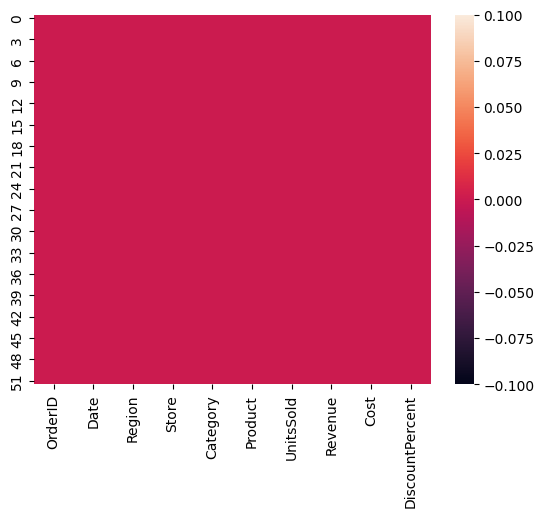

In [12]:
print(df.isnull().sum())
sns.heatmap(df.isnull())

In [13]:
# Fix Numeric Data Types
df['UnitsSold'] = pd.to_numeric(df['UnitsSold'], errors='coerce')
df['Revenue'] = df['Revenue'].replace(r'[$,]', "", regex=True)
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Cost'] = df['Cost'].replace(r'[$,]', "", regex=True)
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

In [14]:
# Fix date types
df['Date'] = pd.to_datetime(df['Date'], format='mixed',errors='coerce')

In [15]:
# Missing values calculated at 3.8% of the total records, so dropped
df = df.dropna(subset=['Date', 'UnitsSold'])

In [16]:
df.isnull().sum()

OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    0
dtype: int64

In [17]:
# check and drop duplicates
print('Dups Before', df.duplicated().sum())
df = df.drop_duplicates()
print('Dups After:',df.duplicated().sum())

Dups Before 2
Dups After: 0


In [18]:
# Feature Creation
df['Profit'] = df['Revenue'] - df['Cost']
df['ProfitMargin'] = df['Profit'] / df['Revenue']

In [19]:
# Create the KPI
df['HighProfit'] = df['Profit'] > 100

### Load

In [20]:
df.to_csv('cleaned_data.csv', index=False)

## Quick Analysis

In [21]:
print('Data Sample')
print(df.head())

Data Sample
   OrderID       Date Region            Store Category     Product  UnitsSold  \
0     1001 2026-05-01   East  Providence Cafe   Coffee       Latte       45.0   
1     1002 2026-05-01   East  Providence Cafe     Food      Muffin       30.0   
2     1003 2026-05-01   West  Seattle Central   Coffee   Cold Brew       52.0   
3     1004 2026-05-02  South     Austin Beans      Tea  Chai Latte       28.0   
4     1005 2026-05-02   West  Seattle Central     Food       Bagel       40.0   

   Revenue   Cost  DiscountPercent  Profit  ProfitMargin  HighProfit  
0    247.5  135.0              0.0   112.5      0.454545        True  
1    105.0   42.0             10.0    63.0      0.600000       False  
2    286.0  140.0              5.0   146.0      0.510490        True  
3    126.0   56.0              0.0    70.0      0.555556       False  
4    140.0   52.0             15.0    88.0      0.628571       False  


In [22]:
print('Profit By Store --')
print(df.groupby('Store')['Profit'].sum())

Profit By Store --
Store
Austin Beans       1491.0
Providence Cafe    1571.0
Seattle Central    1163.5
Name: Profit, dtype: float64


In [23]:
print('Profit By Category --')
print(df.groupby('Category')['Profit'].sum())

Profit By Category --
Category
Coffee    2471.0
Food      1072.0
Tea        682.5
Name: Profit, dtype: float64


In [24]:
print('Profit By Region --')
print(df.groupby('Region')['Profit'].sum())

Profit By Region --
Region
East     1571.0
South    1491.0
West     1163.5
Name: Profit, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['font.size'] = 10
mpl.rcParams['font.family'] = 'sans-serif'

## Professional Visualizations

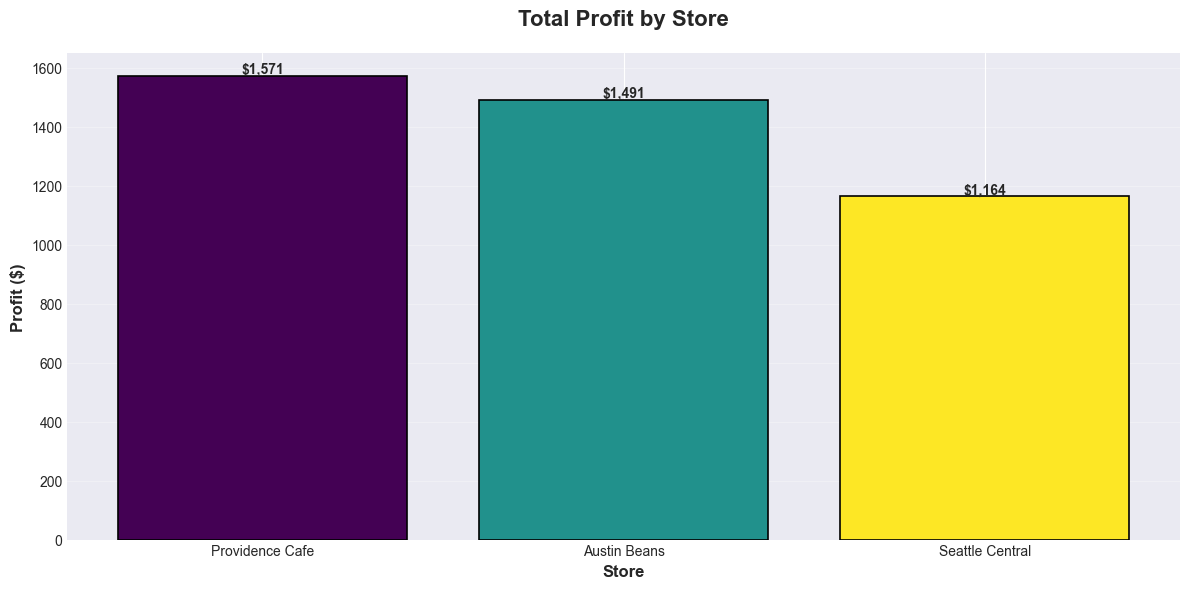

In [26]:
# Chart 1: Profit by Store
fig, ax = plt.subplots(figsize=(12, 6))
profit_by_store = df.groupby('Store')['Profit'].sum().sort_values(ascending=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(profit_by_store)))
bars = ax.bar(profit_by_store.index, profit_by_store.values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_title('Total Profit by Store', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Store', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

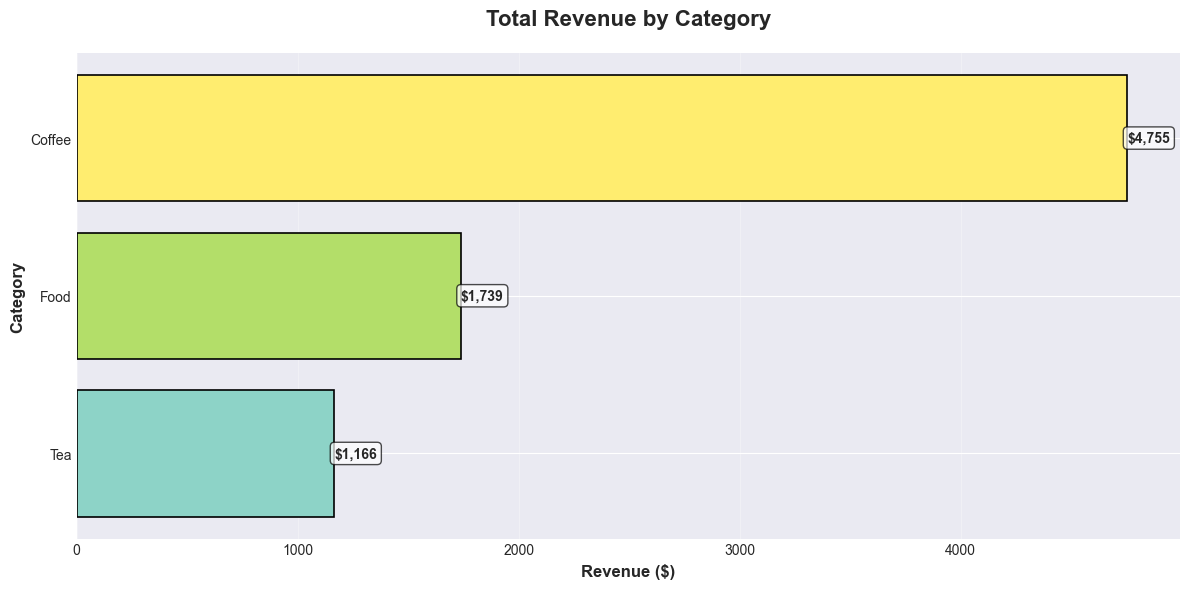

In [27]:
# Chart 2: Revenue by Category
fig, ax = plt.subplots(figsize=(12, 6))
revenue_by_category = df.groupby('Category')['Revenue'].sum().sort_values(ascending=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(revenue_by_category)))
bars = ax.barh(revenue_by_category.index, revenue_by_category.values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_title('Total Revenue by Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'${width:,.0f}', ha='left', va='center', fontsize=10, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.show()

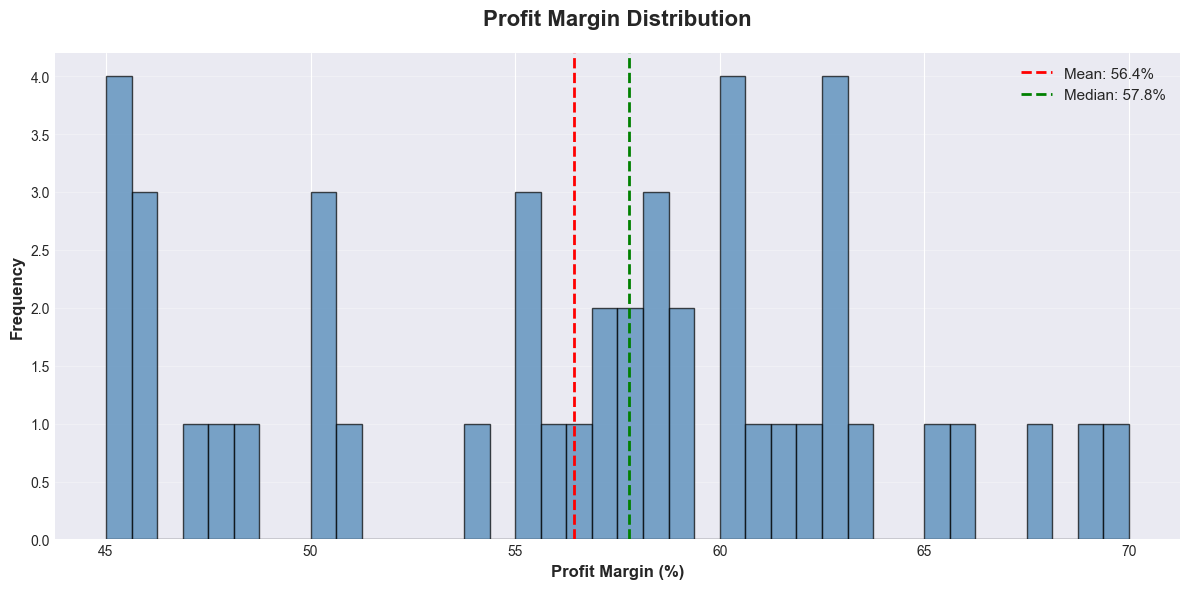

In [28]:
# Chart 3: Profit Margin Distribution
fig, ax = plt.subplots(figsize=(12, 6))
profit_margin_pct = df['ProfitMargin'] * 100
ax.hist(profit_margin_pct.dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(profit_margin_pct.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {profit_margin_pct.mean():.1f}%')
ax.axvline(profit_margin_pct.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {profit_margin_pct.median():.1f}%')
ax.set_title('Profit Margin Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Profit Margin (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

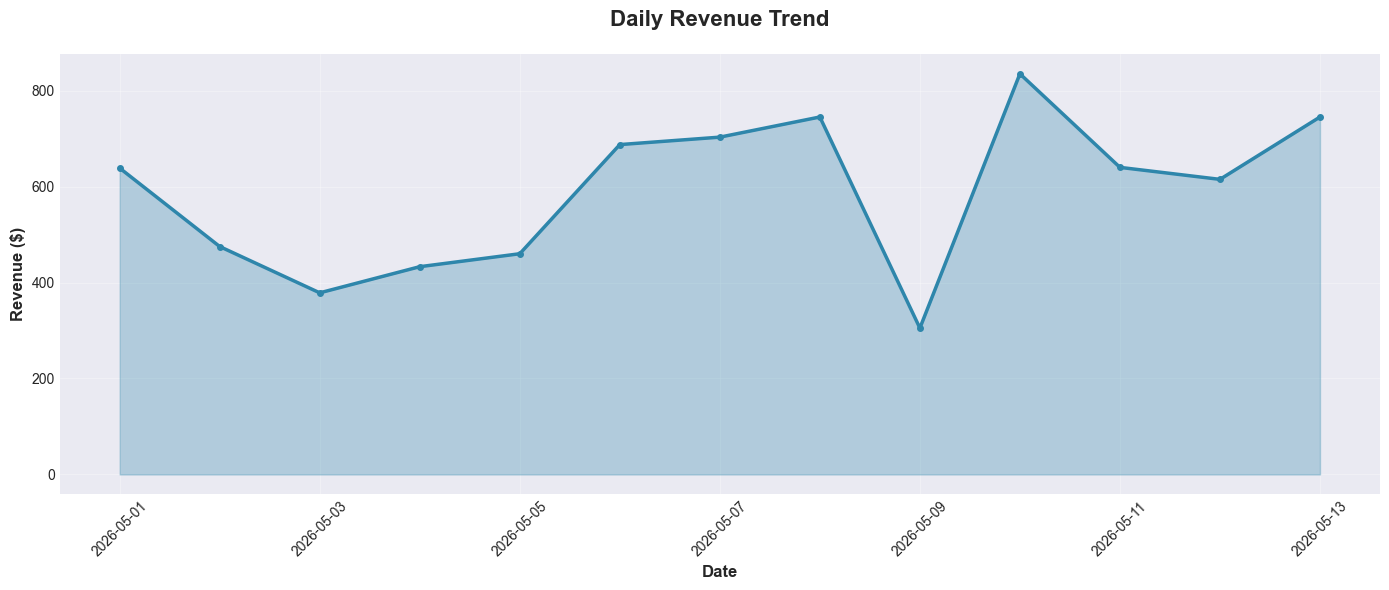

In [29]:
# Chart 4: Revenue Trend Over Time
fig, ax = plt.subplots(figsize=(14, 6))
daily_revenue = df.groupby(df['Date'].dt.date)['Revenue'].sum().sort_index()
ax.plot(daily_revenue.index, daily_revenue.values, marker='o', linewidth=2.5, markersize=4, color='#2E86AB')
ax.fill_between(daily_revenue.index, daily_revenue.values, alpha=0.3, color='#2E86AB')
ax.set_title('Daily Revenue Trend', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

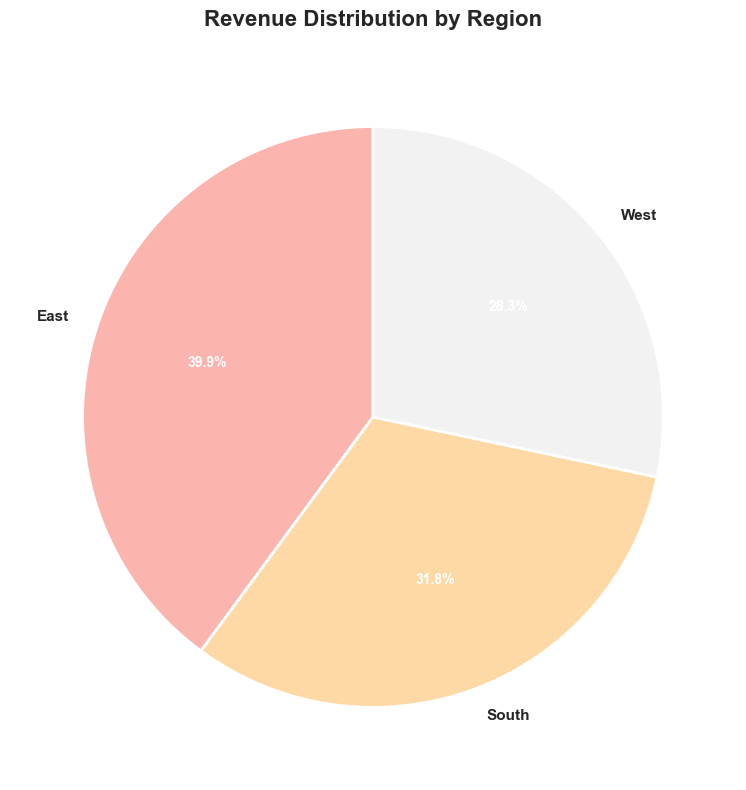

In [30]:
# Chart 5: Sales by Region (Pie Chart)
fig, ax = plt.subplots(figsize=(10, 8))
sales_by_region = df.groupby('Region')['Revenue'].sum()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(sales_by_region)))
wedges, texts, autotexts = ax.pie(sales_by_region.values, labels=sales_by_region.index, autopct='%1.1f%%',
                                    colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Revenue Distribution by Region', fontsize=16, fontweight='bold', pad=20)
# Enhance pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
for wedge in wedges:
    wedge.set_edgecolor('white')
    wedge.set_linewidth(2)
plt.tight_layout()
plt.show()

C:\Users\hueyn\AppData\Local\Temp\ipykernel_17116\4176109306.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(profit_data, labels=regions, patch_artist=True, widths=0.6,


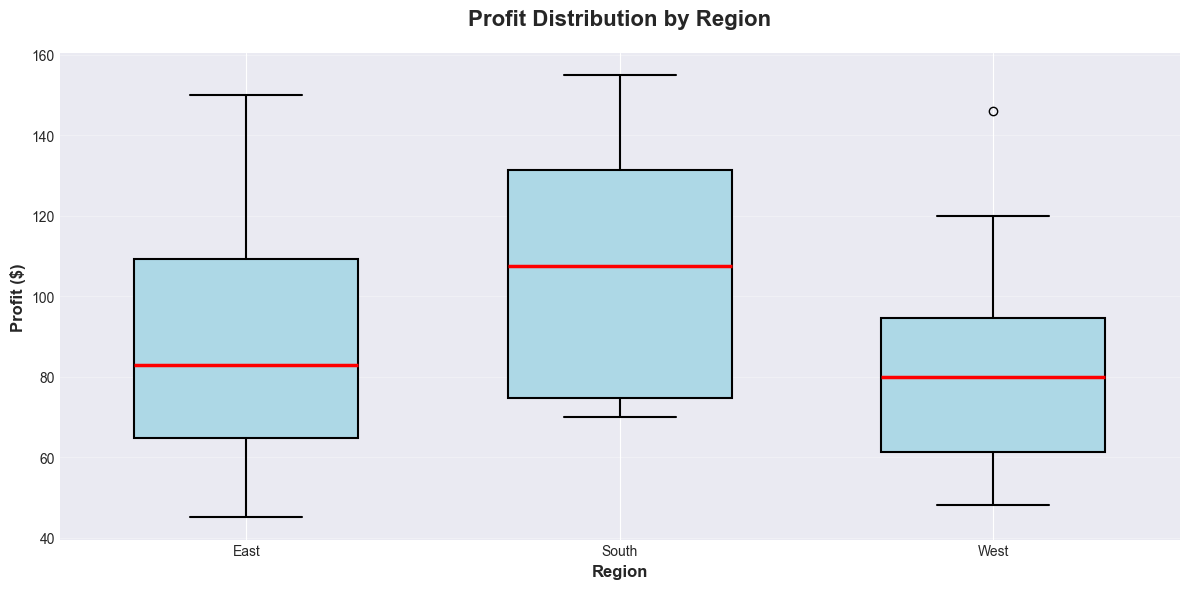

In [31]:
# Chart 6: Profit Comparison by Region (Box Plot)
fig, ax = plt.subplots(figsize=(12, 6))
regions = sorted(df['Region'].unique())
profit_data = [df[df['Region'] == region]['Profit'].dropna().values for region in regions]
bp = ax.boxplot(profit_data, labels=regions, patch_artist=True, widths=0.6,
                  boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2.5))
ax.set_title('Profit Distribution by Region', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

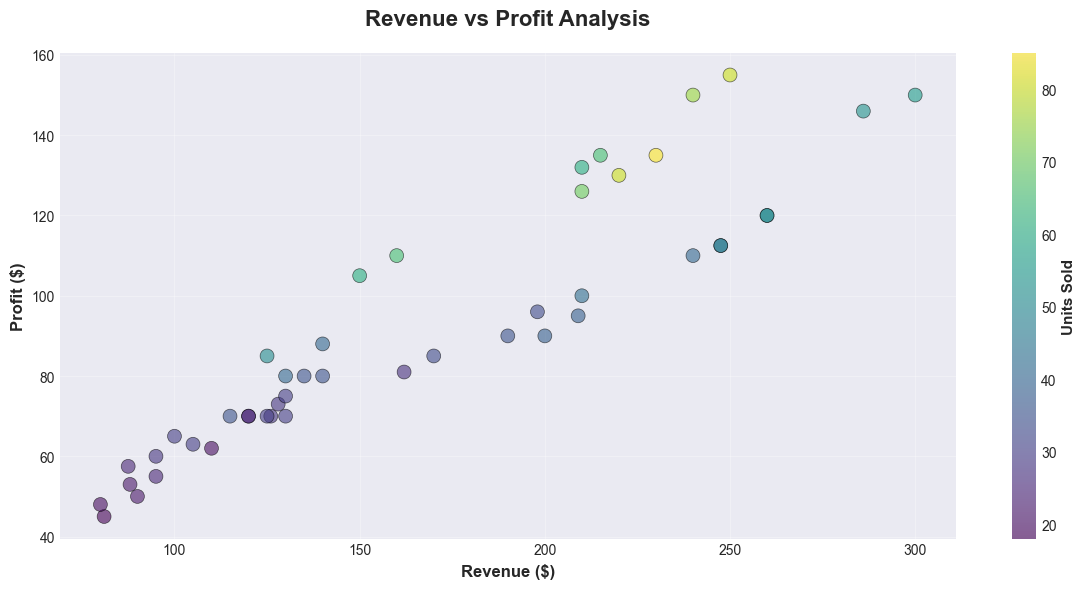

In [32]:
# Chart 7: Revenue vs Profit Scatter Plot
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df['Revenue'], df['Profit'], c=df['UnitsSold'], cmap='viridis', 
                     alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
ax.set_title('Revenue vs Profit Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Units Sold', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

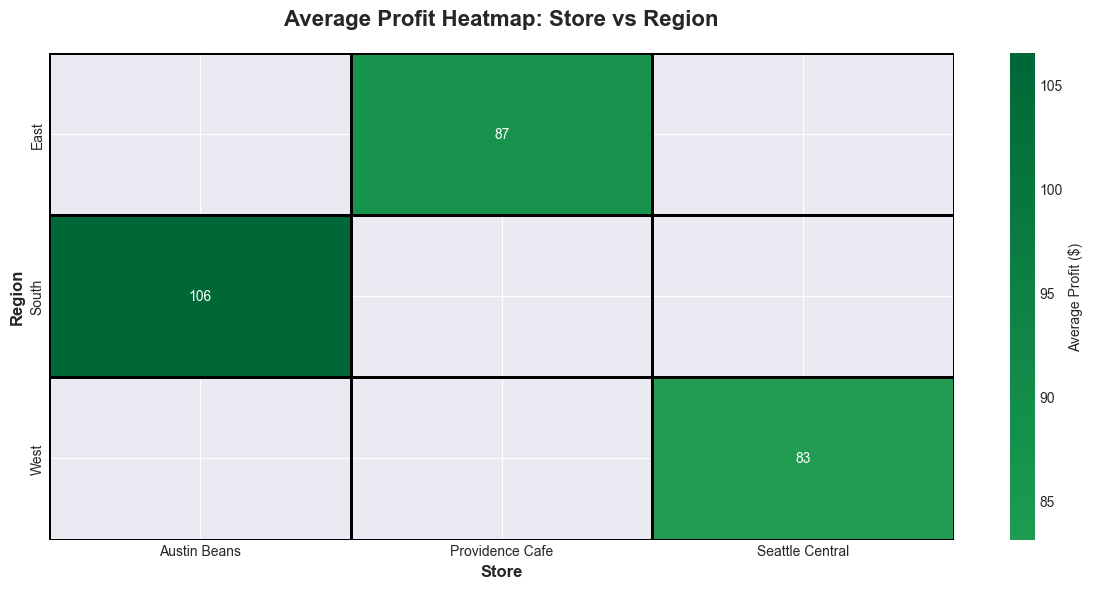

In [33]:
# Chart 8: Heatmap - Average Profit by Store and Region
fig, ax = plt.subplots(figsize=(12, 6))
pivot_data = df.pivot_table(values='Profit', index='Region', columns='Store', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Average Profit ($)'}, linewidths=1, linecolor='black', ax=ax)
ax.set_title('Average Profit Heatmap: Store vs Region', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Store', fontsize=12, fontweight='bold')
ax.set_ylabel('Region', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Sales Forecasting & Insights

In [ ]:
# Sales Forecasting - Simple Trend Analysis
from scipy import stats

daily_data = df.groupby(df['Date'].dt.date).agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'UnitsSold': 'sum'
}).reset_index()

# Calculate trend
x = np.arange(len(daily_data))
slope_revenue, intercept_revenue, r_value, p_value, std_err = stats.linregress(x, daily_data['Revenue'])
slope_profit, intercept_profit, _, _, _ = stats.linregress(x, daily_data['Profit'])

# Forecast next 7 days
forecast_days = 7
future_x = np.arange(len(daily_data), len(daily_data) + forecast_days)
forecast_revenue = slope_revenue * future_x + intercept_revenue
forecast_profit = slope_profit * future_x + intercept_profit

print(f"📈 REVENUE TREND: ${slope_revenue:.2f}/day (R² = {r_value**2:.3f})")
print(f"📈 PROFIT TREND: ${slope_profit:.2f}/day")
print(f"\n🔮 7-DAY FORECAST:")
print(f"   Projected Revenue: ${forecast_revenue.mean():,.2f}/day")
print(f"   Projected Profit: ${forecast_profit.mean():,.2f}/day")

In [ ]:
# Chart 9: Revenue Forecast with Trend Line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Revenue Forecast
ax1.plot(daily_data.index, daily_data['Revenue'], marker='o', label='Historical', linewidth=2, markersize=5, color='#2E86AB')
trend_line = slope_revenue * x + intercept_revenue
ax1.plot(x, trend_line, '--', label='Trend', linewidth=2.5, color='orange', alpha=0.7)
ax1.plot(future_x, forecast_revenue, 'o-', label='Forecast', linewidth=2.5, markersize=8, color='red', alpha=0.8)
ax1.fill_between(x, trend_line - std_err*10, trend_line + std_err*10, alpha=0.2, color='orange')
ax1.set_title('Revenue Forecast (7-Day Projection)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Days', fontsize=11, fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# Profit Forecast
ax2.plot(daily_data.index, daily_data['Profit'], marker='s', label='Historical', linewidth=2, markersize=5, color='#06A77D')
trend_line_profit = slope_profit * x + intercept_profit
ax2.plot(x, trend_line_profit, '--', label='Trend', linewidth=2.5, color='purple', alpha=0.7)
ax2.plot(future_x, forecast_profit, 's-', label='Forecast', linewidth=2.5, markersize=8, color='red', alpha=0.8)
ax2.set_title('Profit Forecast (7-Day Projection)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Days', fontsize=11, fontweight='bold')
ax2.set_ylabel('Profit ($)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Key Business Insights
print("\n" + "="*70)
print("📊 KEY BUSINESS INSIGHTS & METRICS")
print("="*70)

# Overall KPIs
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
avg_profit_margin = df['ProfitMargin'].mean() * 100
avg_order_value = df['Revenue'].sum() / len(df)

print(f"\n💰 FINANCIAL SUMMARY:")
print(f"   Total Revenue: ${total_revenue:,.2f}")
print(f"   Total Profit: ${total_profit:,.2f}")
print(f"   Avg Profit Margin: {avg_profit_margin:.1f}%")
print(f"   Avg Order Value: ${avg_order_value:.2f}")

# Top performers
top_store = df.groupby('Store')['Profit'].sum().idxmax()
top_category = df.groupby('Category')['Profit'].sum().idxmax()
top_region = df.groupby('Region')['Profit'].sum().idxmax()

print(f"\n🏆 TOP PERFORMERS:")
print(f"   Best Store: {top_store} (${df[df['Store']==top_store]['Profit'].sum():,.2f})")
print(f"   Best Category: {top_category} (${df[df['Category']==top_category]['Profit'].sum():,.2f})")
print(f"   Best Region: {top_region} (${df[df['Region']==top_region]['Profit'].sum():,.2f})")

# Performance indicators
high_profit_pct = (df['HighProfit'].sum() / len(df)) * 100
avg_units_sold = df['UnitsSold'].mean()
units_per_dollar = df['UnitsSold'].sum() / total_revenue

print(f"\n📈 PERFORMANCE INDICATORS:")
print(f"   High Profit Sales: {high_profit_pct:.1f}% of transactions")
print(f"   Avg Units Sold/Order: {avg_units_sold:.1f}")
print(f"   Units per Dollar Revenue: {units_per_dollar:.3f}")

# Risk analysis
low_profit = df[df['Profit'] < 0]
low_profit_pct = (len(low_profit) / len(df)) * 100

print(f"\n⚠️ RISK ANALYSIS:")
print(f"   Loss-making Orders: {len(low_profit)} ({low_profit_pct:.2f}%)")
print(f"   Total Loss Impact: ${low_profit['Profit'].sum():,.2f}")
print(f"   Avg Loss per Order: ${low_profit['Profit'].mean():.2f}")

In [ ]:
# Chart 10: Performance Comparison - Revenue vs Profit by Store
fig, ax = plt.subplots(figsize=(14, 6))

store_metrics = df.groupby('Store').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).sort_values('Revenue', ascending=False)

x_pos = np.arange(len(store_metrics))
width = 0.35

bars1 = ax.bar(x_pos - width/2, store_metrics['Revenue'], width, label='Revenue', 
               color='#2E86AB', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, store_metrics['Profit'], width, label='Profit',
               color='#06A77D', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Store', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($)', fontsize=12, fontweight='bold')
ax.set_title('Store Performance: Revenue vs Profit Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(store_metrics.index)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1000:.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Chart 11: Category Performance Matrix
fig, ax = plt.subplots(figsize=(12, 7))

category_metrics = df.groupby('Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'UnitsSold': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

# Create bubble chart
scatter = ax.scatter(category_metrics['Revenue'], category_metrics['Profit'],
                     s=category_metrics['UnitsSold']*2, alpha=0.6,
                     c=category_metrics['ProfitMargin']*100, cmap='RdYlGn',
                     edgecolors='black', linewidth=2, vmin=40, vmax=70)

# Add labels for each bubble
for idx, row in category_metrics.iterrows():
    ax.annotate(row['Category'], 
                (row['Revenue'], row['Profit']),
                fontsize=11, fontweight='bold', ha='center', va='center')

ax.set_xlabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax.set_title('Category Performance Matrix\n(Bubble size = Units Sold, Color = Profit Margin %)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Profit Margin (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Strategic Recommendations
print("\n" + "="*70)
print("💡 STRATEGIC RECOMMENDATIONS")
print("="*70)

# Find underperforming stores
store_profit = df.groupby('Store')['Profit'].sum().sort_values()
avg_store_profit = df.groupby('Store')['Profit'].sum().mean()
underperforming = store_profit[store_profit < avg_store_profit]

print(f"\n1️⃣ STORE OPTIMIZATION:")
if len(underperforming) > 0:
    for store in underperforming.index:
        gap = avg_store_profit - store_profit[store]
        print(f"   • {store}: ${gap:,.0f} below average - Focus on revenue growth")
else:
    print(f"   ✅ All stores performing above average")

# Category insights
category_profit = df.groupby('Category')['Profit'].sum().sort_values()
print(f"\n2️⃣ CATEGORY FOCUS:")
print(f"   • {category_profit.idxmax()}: Top performer - Increase investment")
print(f"   • {category_profit.idxmin()}: Underperformer - Review pricing strategy")

# Discount analysis
discount_impact = df[df['DiscountPercent'] > 0]['Profit'].mean()
no_discount = df[df['DiscountPercent'] == 0]['Profit'].mean()
print(f"\n3️⃣ DISCOUNT STRATEGY:")
if discount_impact < no_discount:
    print(f"   ⚠️ Discounts reduce profitability by ${no_discount - discount_impact:.2f}/order")
    print(f"   • Consider selective discounting or volume incentives")
else:
    print(f"   ✅ Discounts improve profitability by ${discount_impact - no_discount:.2f}/order")

# Regional expansion
region_growth = df.groupby('Region').agg({'Revenue': 'sum', 'Profit': 'sum'})
region_margin = (region_growth['Profit'] / region_growth['Revenue'] * 100)
best_margin = region_margin.idxmax()
print(f"\n4️⃣ EXPANSION OPPORTUNITY:")
print(f"   • {best_margin} has highest margin ({region_margin[best_margin]:.1f}%) - Prioritize growth")

print("\n" + "="*70)